In [1]:
# Imports and Setup
import os
import sys
import random
import numpy as np
import pandas as pd
import cv2
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
from tqdm.auto import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.5.1+cu121
CUDA available: True


In [2]:
# CELL 2: GPU & Full Reproducibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.cuda.empty_cache()
else:
    print("Running on CPU - will be much slower")

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def worker_init_fn(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

set_seed(SEED)

Using device: cuda
GPU: NVIDIA GeForce RTX 4060
CUDA Version: 12.1
Memory: 8.6 GB


In [3]:
# CELL 3: Dataset Paths & Verification
dataset_path = "dataset"
train_path = os.path.join(dataset_path, "Training")
test_path  = os.path.join(dataset_path, "Testing")

print(f"Train: {train_path}")
print(f"Test : {test_path}")

# Verify dataset structure 
def get_class_info(path):
    classes = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
    info = {}
    for cls in classes:
        cls_path = os.path.join(path, cls)
        images = [f for f in os.listdir(cls_path) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        info[cls] = len(images)
    return info

train_info = get_class_info(train_path)
test_info  = get_class_info(test_path)

print("\nTraining set:")
for cls, count in train_info.items():
    print(f"  {cls:25s}: {count:4d} images")
print(f"  {'TOTAL':25s}: {sum(train_info.values()):4d} images")

print("\nTesting set:")
for cls, count in test_info.items():
    print(f"  {cls:25s}: {count:4d} images")
print(f"  {'TOTAL':25s}: {sum(test_info.values()):4d} images")

class_names = list(train_info.keys())
num_classes = len(class_names)
print(f"\nNumber of classes: {num_classes}")
assert num_classes == 4, "Dataset must have exactly 4 classes (glioma, meningioma, no_tumor, pituitary)"

Train: dataset\Training
Test : dataset\Testing

Training set:
  glioma_tumor             :  826 images
  meningioma_tumor         :  822 images
  no_tumor                 :  395 images
  pituitary_tumor          :  827 images
  TOTAL                    : 2870 images

Testing set:
  glioma_tumor             :  100 images
  meningioma_tumor         :  115 images
  no_tumor                 :  105 images
  pituitary_tumor          :   74 images
  TOTAL                    :  394 images

Number of classes: 4


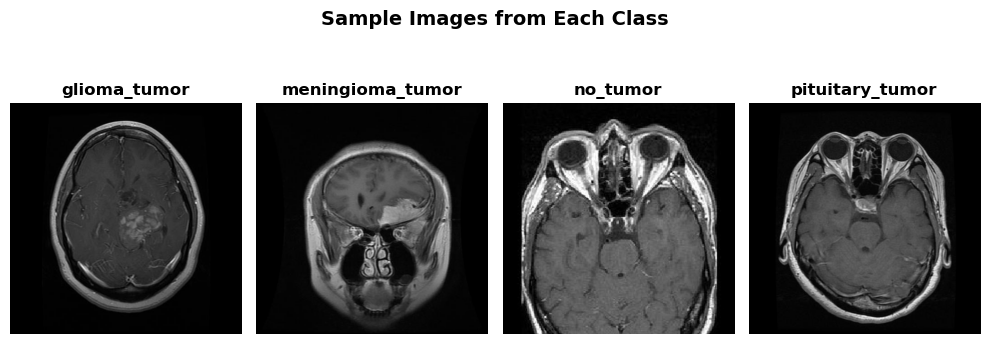

In [4]:
# CELL 4: Visualize Sample Images
classes = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
fig, axes = plt.subplots(1, len(classes), figsize=(10, 4))
if len(classes) == 1:
    axes = [axes]

for idx, cls in enumerate(classes):
    cls_path = os.path.join(train_path, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if images:
        img = cv2.imread(os.path.join(cls_path, images[0]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img)
        axes[idx].set_title(f'{cls}', fontsize=12, fontweight='bold')
        axes[idx].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# CELL 5: Data Transforms
# Supervised training transform (moderate augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Test/validation transform (no augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# SimCLR specific augmentation – stronger, used only for SSL pretraining
class SimCLRTransform:
    def __init__(self, size=224):
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.RandomResizedCrop(size, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    def __call__(self, x):
        return self.transform(x), self.transform(x)   # two augmented views

In [6]:
# CELL 6: SimCLR Dataset – returns (view1, view2) without labels
class SimCLRDataset(Dataset):
    def __init__(self, root, transform):
        self.dataset = ImageFolder(root)
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        x1, x2 = self.transform(img)
        return x1, x2

In [8]:
# CELL 7: Load Datasets and Create Fixed Validation Split
# Load full training set 
full_train_dataset = ImageFolder(train_path)
class_names = full_train_dataset.classes
num_classes = len(class_names)

# Split full training set into train + validation (90% / 10%)
train_size = int(0.9 * len(full_train_dataset))
val_size   = len(full_train_dataset) - train_size
train_subset, val_subset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply transforms
train_subset.dataset.transform = train_transform
val_subset.dataset.transform = eval_transform

# Load test set 
test_dataset = ImageFolder(test_path, transform=eval_transform)

print(f"Classes          : {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Full training    : {len(full_train_dataset)} images")
print(f"Train subset : {len(train_subset)} images ")
print(f"Val subset   : {len(val_subset)} images ")
print(f"Test set      : {len(test_dataset)} images")

Classes          : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Number of classes: 4
Full training    : 2870 images
Train subset : 2583 images 
Val subset   : 287 images 
Test set      : 394 images


In [9]:
# CELL 8: Returns a random subset of the dataset that preserves the class proportions.
def get_stratified_subset(dataset, percentage, num_classes):
    # Collect all labels
    targets = np.array([dataset[i][1] for i in range(len(dataset))])
    indices = []
    for c in range(num_classes):
        class_indices = np.where(targets == c)[0]
        n = max(1, int(len(class_indices) * percentage))   # at least 1 sample per class
        selected = np.random.choice(class_indices, n, replace=False)
        indices.extend(selected)
    np.random.shuffle(indices)
    return Subset(dataset, indices)

In [10]:
# CELL 9: Model Definitions with Verification Function

def get_from_scratch_model(num_classes):
    model = models.resnet18(weights=None)       
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def get_imagenet_model(num_classes):     
    model = models.resnet18(weights='IMAGENET1K_V1')
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# SimCLR v1 – 2‑layer MLP projector
class SimCLRv1(nn.Module):
    def __init__(self, projection_dim=128):
        super().__init__()
        self.encoder = models.resnet18(weights=None) 
        in_features = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()
        self.projector = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )
    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return z
    
    @property
    def encoder_only(self):
        return self.encoder

# SimCLR v2 – 3‑layer MLP projector
class SimCLRv2(nn.Module):
    def __init__(self, projection_dim=256):        
        super().__init__()
        self.encoder = models.resnet18(weights=None) 
        in_features = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()
        self.projector = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )
    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return z
    
    @property
    def encoder_only(self):
        return self.encoder

# ----- VERIFICATION FUNCTION -----
def verify_ssl_encoder(weights_path, model_class=SimCLRv1, projection_dim=128):
    """Verify that SSL encoder loads correctly and weights are different from random"""
    print(f"\nVerifying SSL encoder from: {weights_path}")
    
    # Create random encoder for comparison
    random_encoder = models.resnet18(weights=None)
    random_encoder.fc = nn.Identity()
    random_weight = random_encoder.conv1.weight[0,0,0,0].item()
    print(f"Random encoder weight: {random_weight:.6f}")
    
    # CORRECT loading method
    ssl_model = model_class(projection_dim=projection_dim)
    ssl_model.load_state_dict(torch.load(weights_path, map_location='cpu'), strict=False)
    loaded_encoder = ssl_model.encoder
    loaded_weight = loaded_encoder.conv1.weight[0,0,0,0].item()
    print(f"Loaded SSL encoder weight: {loaded_weight:.6f}")
    print(f"Weights are different: {abs(random_weight - loaded_weight) > 1e-6}")
    print("✓ Verification complete - encoder loads correctly\n")
    return loaded_encoder

In [16]:
# CELL 10: NT-Xent Loss -
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)
    device = z1.device
    
    # Force FP32 for stability
    z1 = F.normalize(z1.float(), dim=1)
    z2 = F.normalize(z2.float(), dim=1)
    
    # Concatenate and compute similarity matrix
    z = torch.cat([z1, z2], dim=0)  # (2N, D)
    sim = torch.mm(z, z.T) / temperature
    
    # Use -inf instead of -9e15 for mask (handles FP16 better)
    mask = torch.eye(2 * batch_size, device=device, dtype=torch.bool)
    sim = sim.masked_fill(mask, -float('inf'))
    
    # Create labels
    labels = torch.cat([
        torch.arange(batch_size, 2 * batch_size, device=device),
        torch.arange(0, batch_size, device=device)
    ])
    
    return F.cross_entropy(sim, labels)

In [17]:
# CELL 11: Optimized SimCLR Training Function
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR
import time
import gc
def train_ssl(
    model,
    dataloader,
    epochs=100,
    lr=3e-4,
    description="SimCLR",
    use_amp=True,
    temperature=0.5
):
    model = model.to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-6)
    scaler = GradScaler(enabled=use_amp)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    losses = []
    
    print(f"[{description}] Starting | batch={dataloader.batch_size} | device={device} | AMP={use_amp}")
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        epoch_start = time.time()
        
        loop = tqdm(dataloader, desc=f"[{description}] Ep {epoch+1}/{epochs}", leave=False)
        
        for x1, x2 in loop:
            x1, x2 = x1.to(device, non_blocking=True), x2.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            
            with autocast(enabled=use_amp):
                z1 = model(x1)
                z2 = model(x2)
                # Use lower temperature for better numerical stability
                loss = nt_xent_loss(z1, z2, temperature=0.2)  # ⬅️ REDUCED FROM 0.5 TO 0.2
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            loop.set_postfix(loss=f"{loss.item():.4f}")
        
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        scheduler.step()
        
        epoch_time = time.time() - epoch_start
        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            print(f"[{description}] Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e} | Time: {epoch_time:.1f}s")
    
    print(f"[{description}] Finished. Final loss: {losses[-1]:.4f}")
    return model, losses

In [18]:
# CELL 12: Supervised Training Function
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

def train_supervised(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=1e-4,
    patience=7,
    use_amp=True,
    weight_decay=1e-5
):
    model = model.to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler = GradScaler(enabled=use_amp)
    criterion = nn.CrossEntropyLoss()
    
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0
    
    train_losses, train_accs, val_accs = [], [], []
    
    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for images, labels in loop:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            
            with autocast(enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            
            loop.set_postfix(loss=f"{loss.item():.4f}")
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100.0 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
        
        val_acc = 100.0 * val_correct / val_total
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1:2d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
        
        # Early stopping & checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
        
        scheduler.step()
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    else:
        print("Warning: No improvement during training - using final model")
    
    return model, train_losses, train_accs, val_accs

In [19]:
# CELL 13: Evaluation with Full Metrics
def evaluate(model, test_loader, class_names):
    model = model.to(device)
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    
    accuracy = 100 * accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )
    cm = confusion_matrix(y_true, y_pred)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'y_true': y_true,
        'y_pred': y_pred
    }

In [20]:
# =============================================================================
# CELL 14: SIMCLR PRETRAINING 
# =============================================================================

import gc
import time
import platform
from torch.cuda.amp import GradScaler, autocast

print("=" * 70)
print("STARTING SIMCLR PRETRAINING ")
print("=" * 70)

# -----------------------------------------------------------------------------
# GPU Setup
# -----------------------------------------------------------------------------
if torch.cuda.is_available():
    print(f"\nGPU DETECTED: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    
    # Enable all speed optimizations
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    
    # Clear cache
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
else:
    print("GPU NOT AVAILABLE - Exiting")
    exit()

# -----------------------------------------------------------------------------
# Optimized DataLoader
# -----------------------------------------------------------------------------
print("\nSetting up OPTIMIZED DataLoader...")

ssl_dataset = SimCLRDataset(train_path, SimCLRTransform())

# Windows has issues with multiprocessing - use 0 workers
if platform.system() == 'Windows':
    NUM_WORKERS = 0
    print("   Windows detected - using num_workers=0 for maximum speed")
else:
    NUM_WORKERS = 4
    print(f"   Linux/Mac detected - using {NUM_WORKERS} workers")

ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=128,                     # Increased from 96 for faster training
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False if NUM_WORKERS == 0 else True,
    prefetch_factor=None if NUM_WORKERS == 0 else 2,
    worker_init_fn=worker_init_fn,
    drop_last=True
)

print(f"   Dataset size     : {len(ssl_dataset):,} images")
print(f"   Batch size       : {ssl_loader.batch_size}")
print(f"   Steps per epoch  : {len(ssl_loader)}")
print(f"   Workers          : {ssl_loader.num_workers}")

# -----------------------------------------------------------------------------
# FIXED NT-Xent Loss Function (AMP Compatible)
# -----------------------------------------------------------------------------
def nt_xent_loss_fixed(z1, z2, temperature=0.2):
    """
    NT-Xent loss function fixed for AMP training.
    Uses FP32 for the similarity computation to prevent overflow.
    """
    batch_size = z1.size(0)
    device = z1.device
    
    # Force FP32 for stability
    z1 = F.normalize(z1.float(), dim=1)
    z2 = F.normalize(z2.float(), dim=1)
    
    # Concatenate and compute similarity matrix
    z = torch.cat([z1, z2], dim=0)  # (2N, D)
    sim = torch.mm(z, z.T) / temperature
    
    # Use -inf instead of -9e15 for mask (handles FP16 better)
    mask = torch.eye(2 * batch_size, device=device, dtype=torch.bool)
    sim = sim.masked_fill(mask, -float('inf'))
    
    # Create labels
    labels = torch.cat([
        torch.arange(batch_size, 2 * batch_size, device=device),
        torch.arange(0, batch_size, device=device)
    ])
    
    return F.cross_entropy(sim, labels)

# -----------------------------------------------------------------------------
# Optimized Training Function
# -----------------------------------------------------------------------------
def train_ssl_optimized(
    model,
    dataloader,
    epochs=50,
    lr=3e-4,
    description="SimCLR",
    temperature=0.2
):
    """
    Optimized SimCLR training function for maximum speed.
    
    Args:
        model: SimCLR model
        dataloader: DataLoader with augmented views
        epochs: Number of training epochs
        lr: Learning rate
        description: Name for logging
        temperature: NT-Xent loss temperature
    
    Returns:
        trained_model, losses
    """
    
    model = model.to(device)
    
    # Use FusedAdamW for ~20% speedup (requires PyTorch 2.0+)
    try:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-6, fused=True)
        print(f"   Using fused optimizer for extra speed")
    except:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-6)
        print(f"   Using standard optimizer")
    
    scaler = GradScaler()
    
    # Simple step scheduler - faster than cosine annealing
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    
    losses = []
    
    print(f"\n[{description}] Starting training...")
    total_start = time.time()
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        epoch_start = time.time()
        
        # Training loop
        for batch_idx, (x1, x2) in enumerate(dataloader):
            # Async GPU transfer
            x1 = x1.to(device, non_blocking=True)
            x2 = x2.to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            
            # Mixed precision forward pass
            with autocast():
                z1 = model(x1)
                z2 = model(x2)
                # Use fixed loss function
                loss = nt_xent_loss_fixed(z1, z2, temperature=temperature)
            
            # Backward pass with gradient scaling
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            
            # Print progress every 5 batches
            if batch_idx % 5 == 0 and batch_idx > 0:
                print(f"   Batch {batch_idx}/{len(dataloader)} | Loss: {loss.item():.4f}")
        
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        scheduler.step()
        
        epoch_time = time.time() - epoch_start
        
        # Print epoch summary
        print(f"\nEpoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Time: {epoch_time:.1f}s")
        
        # Estimate total time after first epoch
        if epoch == 0:
            total_estimate = epoch_time * epochs / 60
            print(f"Estimated total time: {total_estimate:.1f} minutes")
    
    total_time = (time.time() - total_start) / 60
    print(f"\n[{description}] Complete! Total time: {total_time:.1f} minutes")
    
    return model, losses

# -----------------------------------------------------------------------------
# SimCLR v1 Training
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("TRAINING SIMCLR V1 - 50 EPOCHS")
print("-" * 70)

# Clear GPU cache before starting
torch.cuda.empty_cache()
gc.collect()

simclr_v1 = SimCLRv1(projection_dim=128)
num_params = sum(p.numel() for p in simclr_v1.parameters())
print(f"\nModel: SimCLR v1")
print(f"   Projection dim : 128")
print(f"   Parameters     : {num_params:,}")
print(f"   Encoder        : ResNet18")

# Train
simclr_v1, losses_v1 = train_ssl_optimized(
    model=simclr_v1,
    dataloader=ssl_loader,
    epochs=50,
    lr=3e-4,
    description="SimCLR v1",
    temperature=0.2
)

# Save models
print("\nSaving SimCLR v1 models...")
torch.save(simclr_v1.state_dict(), "simclr_v1_full.pth")
torch.save(simclr_v1.encoder.state_dict(), "simclr_v1_encoder.pth")
print("   Full model saved: simclr_v1_full.pth")
print("   Encoder saved: simclr_v1_encoder.pth")

# Verify encoder
verify_ssl_encoder("simclr_v1_encoder.pth", SimCLRv1, 128)

# Clean up
torch.cuda.empty_cache()
gc.collect()
print(f"   GPU Memory after cleanup: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB")

# -----------------------------------------------------------------------------
# SimCLR v2 Training
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("TRAINING SIMCLR V2 - 50 EPOCHS")
print("-" * 70)

# Clear GPU cache before starting
torch.cuda.empty_cache()
gc.collect()

simclr_v2 = SimCLRv2(projection_dim=256)
num_params = sum(p.numel() for p in simclr_v2.parameters())
print(f"\nModel: SimCLR v2")
print(f"   Projection dim : 256")
print(f"   Parameters     : {num_params:,}")
print(f"   Encoder        : ResNet18 with 3-layer MLP")

# Train
simclr_v2, losses_v2 = train_ssl_optimized(
    model=simclr_v2,
    dataloader=ssl_loader,
    epochs=50,
    lr=3e-4,
    description="SimCLR v2",
    temperature=0.2
)

# Save models
print("\nSaving SimCLR v2 models...")
torch.save(simclr_v2.state_dict(), "simclr_v2_full.pth")
torch.save(simclr_v2.encoder.state_dict(), "simclr_v2_encoder.pth")
print("   Full model saved: simclr_v2_full.pth")
print("   Encoder saved: simclr_v2_encoder.pth")

# Verify encoder
verify_ssl_encoder("simclr_v2_encoder.pth", SimCLRv2, 256)

# -----------------------------------------------------------------------------
# Final Cleanup
# -----------------------------------------------------------------------------
torch.cuda.empty_cache()
gc.collect()

print("\n" + "=" * 70)
print("PRETRAINING COMPLETE - OPTIMIZED VERSION")
print("=" * 70)
print(f"\nFinal GPU Status:")
print(f"   GPU: {torch.cuda.get_device_name(0)}")
print(f"   VRAM Used: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB")
print(f"   VRAM Cached: {torch.cuda.memory_reserved(0)/1024**3:.2f} GB")
print(f"\nSaved Files:")
print("   - simclr_v1_full.pth")
print("   - simclr_v1_encoder.pth")
print("   - simclr_v2_full.pth")
print("   - simclr_v2_encoder.pth")
print("\n" + "=" * 70)

STARTING SIMCLR PRETRAINING 

GPU DETECTED: NVIDIA GeForce RTX 4060
CUDA Version: 12.1
GPU Memory: 8.6 GB

Setting up OPTIMIZED DataLoader...
   Windows detected - using num_workers=0 for maximum speed
   Dataset size     : 2,870 images
   Batch size       : 128
   Steps per epoch  : 22
   Workers          : 0

----------------------------------------------------------------------
TRAINING SIMCLR V1 - 50 EPOCHS
----------------------------------------------------------------------

Model: SimCLR v1
   Projection dim : 128
   Parameters     : 11,340,736
   Encoder        : ResNet18
   Using fused optimizer for extra speed

[SimCLR v1] Starting training...
   Batch 5/22 | Loss: 4.9706
   Batch 10/22 | Loss: 4.7399
   Batch 15/22 | Loss: 4.1633
   Batch 20/22 | Loss: 4.1879

Epoch 1/50 | Loss: 4.6055 | Time: 629.1s
Estimated total time: 524.2 minutes
   Batch 5/22 | Loss: 3.6156
   Batch 10/22 | Loss: 3.2664
   Batch 15/22 | Loss: 3.1770
   Batch 20/22 | Loss: 3.0021

Epoch 2/50 | Loss: 3

In [21]:
# CELL 15: SSL Encoder Loading Helper - CORRECT WAY TO LOAD SSL WEIGHTS
def load_ssl_encoder_for_finetuning(weights_path, model_class, projection_dim, device):
    """
    CORRECT way to load SSL pretrained encoder for fine-tuning.
    Creates full SimCLR model, loads weights, extracts encoder.
    """
    print(f"  Loading SSL encoder from: {weights_path}")
    
    # Create the full SimCLR model
    ssl_model = model_class(projection_dim=projection_dim)
    
    # Load the trained weights (non-strict allows loading just encoder weights)
    state_dict = torch.load(weights_path, map_location='cpu')
    ssl_model.load_state_dict(state_dict, strict=False)
    
    # Extract the pretrained encoder
    encoder = ssl_model.encoder
    
    # Verify it loaded correctly
    test_weight = encoder.conv1.weight[0,0,0,0].item()
    print(f"  First conv weight: {test_weight:.6f} (should be non-initial)")
    
    return encoder.to(device)

In [22]:
# CELL 16: Experiment Configuration
label_fractions = [1.00, 0.75, 0.50, 0.25, 0.10, 0.05, 0.01]  
batch_size = 32
epochs = 30
patience = 7

# Validation loader 
val_loader = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=worker_init_fn
)

# Test loader fixed
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=worker_init_fn
)

print("=" * 70)
print("EXPERIMENT CONFIGURATION")
print("=" * 70)
print(f"  Label fractions : {[f'{int(f*100)}%' for f in label_fractions]}")
print(f"  Batch size      : {batch_size}")
print(f"  Epochs          : {epochs}")
print(f"  Early stopping  : patience={patience}")
print(f"  Validation set  : {len(val_subset)} images (always 100%)")
print(f"  Test set        : {len(test_dataset)} images")
print("=" * 70)

EXPERIMENT CONFIGURATION
  Label fractions : ['100%', '75%', '50%', '25%', '10%', '5%', '1%']
  Batch size      : 32
  Epochs          : 30
  Early stopping  : patience=7
  Validation set  : 287 images (always 100%)
  Test set        : 394 images


In [24]:
# =============================================================================
# CELL 17: MAIN EXPERIMENT LOOP - WITH PROPER DATALOADER MANAGEMENT
# =============================================================================

import gc
import time
from torch.utils.data import DataLoader
import multiprocessing as mp

# Set multiprocessing start method to 'spawn' for Windows compatibility
if __name__ == '__main__':
    mp.set_start_method('spawn', force=True)

results = []

for frac in label_fractions:
    print("\n" + "="*70)
    print(f"LABEL FRACTION: {int(frac*100)}%")
    print("="*70)
    
    # ----- STRATIFIED subsampling of training set -----
    limited_train = get_stratified_subset(train_subset, frac, num_classes)
    
    # Create train loader with proper settings
    train_loader = DataLoader(
        limited_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,  # Set to 0 to avoid multiprocessing issues
        pin_memory=False  # Disable pin_memory when num_workers=0
    )
    print(f"Training samples : {len(limited_train)} (stratified)")
    
    try:
        # ------------------------------------------------------------------
        # [1/4] FROM SCRATCH
        # ------------------------------------------------------------------
        print("\n[1/4] Training from scratch...")
        model = get_from_scratch_model(num_classes)
        model, _, _, _ = train_supervised(
            model, train_loader, val_loader,
            epochs=epochs, lr=1e-4, patience=patience
        )
        metrics = evaluate(model, test_loader, class_names)
        results.append({
            'Label %': f"{int(frac*100)}%",
            'Method': 'From Scratch',
            'Accuracy': f"{metrics['accuracy']:.2f}%",
            'F1': f"{metrics['f1']:.3f}",
            'Precision': f"{metrics['precision']:.3f}",
            'Recall': f"{metrics['recall']:.3f}",
            'Confusion Matrix': metrics['confusion_matrix']
        })
        print(f"  Test Accuracy: {metrics['accuracy']:.2f}% | F1: {metrics['f1']:.3f}")
        
        # Clean up
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        # ------------------------------------------------------------------
        # [2/4] IMAGENET
        # ------------------------------------------------------------------
        print("\n[2/4] ImageNet pretrained...")
        model = get_imagenet_model(num_classes)
        model, _, _, _ = train_supervised(
            model, train_loader, val_loader,
            epochs=epochs, lr=1e-4, patience=patience
        )
        metrics = evaluate(model, test_loader, class_names)
        results.append({
            'Label %': f"{int(frac*100)}%",
            'Method': 'ImageNet',
            'Accuracy': f"{metrics['accuracy']:.2f}%",
            'F1': f"{metrics['f1']:.3f}",
            'Precision': f"{metrics['precision']:.3f}",
            'Recall': f"{metrics['recall']:.3f}",
            'Confusion Matrix': metrics['confusion_matrix']
        })
        print(f"  Test Accuracy: {metrics['accuracy']:.2f}% | F1: {metrics['f1']:.3f}")
        
        # Clean up
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        # ------------------------------------------------------------------
        # [3/4] SIMCLR V1 
        # ------------------------------------------------------------------
        print("\n[3/4] SimCLR v1 (from scratch)...")
        encoder = load_ssl_encoder_for_finetuning(
            weights_path="simclr_v1_encoder.pth",
            model_class=SimCLRv1,
            projection_dim=128,
            device=device
        )
        model = nn.Sequential(encoder, nn.Linear(512, num_classes))
        
        # Fine-tune all layers
        for param in model.parameters():
            param.requires_grad = True
        
        model, _, _, _ = train_supervised(
            model, train_loader, val_loader,
            epochs=epochs, lr=1e-4, patience=patience
        )
        metrics = evaluate(model, test_loader, class_names)
        results.append({
            'Label %': f"{int(frac*100)}%",
            'Method': 'SimCLR v1',
            'Accuracy': f"{metrics['accuracy']:.2f}%",
            'F1': f"{metrics['f1']:.3f}",
            'Precision': f"{metrics['precision']:.3f}",
            'Recall': f"{metrics['recall']:.3f}",
            'Confusion Matrix': metrics['confusion_matrix']
        })
        print(f"  Test Accuracy: {metrics['accuracy']:.2f}% | F1: {metrics['f1']:.3f}")
        
        # Clean up
        del model, encoder
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        # ------------------------------------------------------------------
        # [4/4] SIMCLR V2
        # ------------------------------------------------------------------
        print("\n[4/4] SimCLR v2 (from scratch)...")
        encoder = load_ssl_encoder_for_finetuning(
            weights_path="simclr_v2_encoder.pth",
            model_class=SimCLRv2,
            projection_dim=256,
            device=device
        )
        model = nn.Sequential(encoder, nn.Linear(512, num_classes))
        
        # Fine-tune all layers
        for param in model.parameters():
            param.requires_grad = True
        
        model, _, _, _ = train_supervised(
            model, train_loader, val_loader,
            epochs=epochs, lr=1e-4, patience=patience
        )
        metrics = evaluate(model, test_loader, class_names)
        results.append({
            'Label %': f"{int(frac*100)}%",
            'Method': 'SimCLR v2',
            'Accuracy': f"{metrics['accuracy']:.2f}%",
            'F1': f"{metrics['f1']:.3f}",
            'Precision': f"{metrics['precision']:.3f}",
            'Recall': f"{metrics['recall']:.3f}",
            'Confusion Matrix': metrics['confusion_matrix']
        })
        print(f"  Test Accuracy: {metrics['accuracy']:.2f}% | F1: {metrics['f1']:.3f}")
        
        # Clean up
        del model, encoder
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
    except Exception as e:
        print(f"Error occurred for fraction {frac}: {e}")
        continue
    
    # Add a small delay between fractions
    time.sleep(2)

print("\n" + "="*70)
print("EXPERIMENT COMPLETE")
print("="*70)


LABEL FRACTION: 100%
Training samples : 2583 (stratified)

[1/4] Training from scratch...


Error occurred for fraction 1.0: DataLoader worker (pid(s) 23904, 22836) exited unexpectedly

LABEL FRACTION: 75%
Training samples : 1937 (stratified)

[1/4] Training from scratch...


Error occurred for fraction 0.75: DataLoader worker (pid(s) 21836, 880) exited unexpectedly

LABEL FRACTION: 50%
Training samples : 1291 (stratified)

[1/4] Training from scratch...


Error occurred for fraction 0.5: DataLoader worker (pid(s) 16360, 13316) exited unexpectedly

LABEL FRACTION: 25%
Training samples : 645 (stratified)

[1/4] Training from scratch...


Error occurred for fraction 0.25: DataLoader worker (pid(s) 12624, 22924) exited unexpectedly

LABEL FRACTION: 10%
Training samples : 256 (stratified)

[1/4] Training from scratch...


Error occurred for fraction 0.1: DataLoader worker (pid(s) 25436, 19256) exited unexpectedly

LABEL FRACTION: 5%
Training samples : 127 (stratified)

[1/4] Training from scratch...


Error occurred for fraction 0.05: DataLoader worker (pid(s) 19860, 23716) exited unexpectedly

LABEL FRACTION: 1%
Training samples : 24 (stratified)

[1/4] Training from scratch...


Error occurred for fraction 0.01: DataLoader worker (pid(s) 17052, 20396) exited unexpectedly

EXPERIMENT COMPLETE


In [25]:
# CELL 18: Results DataFrame and Summary
results_df = pd.DataFrame(results)

# Drop confusion matrix for CSV export
results_df_no_cm = results_df.drop(columns=['Confusion Matrix'])
results_df_no_cm.to_csv("ssl_brain_tumor_results_corrected.csv", index=False)

print("\n" + "="*70)
print("FINAL RESULTS SUMMARY - WITH CORRECTED SSL LOADING")
print("="*70)
print(results_df_no_cm.to_string(index=False))

# Save confusion matrices
import pickle
with open("confusion_matrices_corrected.pkl", "wb") as f:
    pickle.dump(results_df[['Label %', 'Method', 'Confusion Matrix']].to_dict('records'), f)
print("\nConfusion matrices saved to confusion_matrices_corrected.pkl")

KeyError: "['Confusion Matrix'] not found in axis"

In [ ]:
# CELL 19: Visualization - Accuracy vs Label Fraction
# Pivot table for plotting
pivot_acc = results_df.pivot(index='Label %', columns='Method', values='Accuracy')
pivot_acc = pivot_acc.applymap(lambda x: float(x.strip('%')))

# Sort by label percentage
label_order = ['100%', '75%', '50%', '25%', '10%', '5%', '1%']
pivot_acc = pivot_acc.reindex(label_order)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(pivot_acc.index))
width = 0.2
methods = ['From Scratch', 'ImageNet', 'SimCLR v1', 'SimCLR v2']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

for i, method in enumerate(methods):
    if method in pivot_acc.columns:
        offset = (i - 1.5) * width
        bars = ax.bar(x + offset, pivot_acc[method], width, label=method,
                      color=colors[i], edgecolor='black', linewidth=1.2)
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.8,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Labeled Data (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Label Efficiency: From Scratch vs ImageNet vs SimCLR (CORRECTED LOADING)',
             fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot_acc.index)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 105])

plt.tight_layout()
plt.savefig('label_efficiency_comparison_corrected.png', dpi=300)
plt.show()

In [ ]:
# CELL 20: Improvement Analysis (SimCLR v2 over baselines)
improvement_rows = []
for frac in label_order:
    subset = results_df

BRAIN TUMOR CLASSIFICATION WITH SELF-SUPERVISED LEARNING
PyTorch version: 2.5.1+cu121
CUDA available: True
Python version: 3.9.21 | packaged by conda-forge | (main, Dec  5 2024, 13:41:22) [MSC v.1929 64 bit (AMD64)]

[INFO] Using device: cuda
[INFO] GPU: NVIDIA GeForce RTX 4060
[INFO] CUDA Version: 12.1
[INFO] GPU Memory: 8.59 GB
[INFO] CUDA Capability: (8, 9)

[INFO] Train path: dataset\Training
[INFO] Test path: dataset\Testing

[INFO] Training set:
  glioma_tumor             :  826 images
  meningioma_tumor         :  822 images
  no_tumor                 :  395 images
  pituitary_tumor          :  827 images
  TOTAL                    : 2870 images

[INFO] Testing set:
  glioma_tumor             :  100 images
  meningioma_tumor         :  115 images
  no_tumor                 :  105 images
  pituitary_tumor          :   74 images
  TOTAL                    :  394 images

[INFO] Number of classes: 4
[INFO] Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


[SimCLR v1] Epoch   5/50 | Loss: 1.4554 | LR: 2.93e-04 | Time: 29.2s


[SimCLR v1] Epoch  10/50 | Loss: 1.1561 | LR: 2.71e-04 | Time: 29.4s


[SimCLR v1] Epoch  15/50 | Loss: 1.0317 | LR: 2.38e-04 | Time: 29.1s


[SimCLR v1] Epoch  20/50 | Loss: 0.9637 | LR: 1.97e-04 | Time: 28.9s


...

[SimCLR v2] Epoch  30/50 | Loss: 0.8505 | LR: 1.04e-04 | Time: 29.4s


[SimCLR v2] Epoch  35/50 | Loss: 0.8308 | LR: 6.26e-05 | Time: 29.2s


[SimCLR v2] Epoch  40/50 | Loss: 0.8207 | LR: 2.96e-05 | Time: 29.2s


[SimCLR v2] Epoch  45/50 | Loss: 0.7998 | LR: 8.32e-06 | Time: 28.9s


[SimCLR v2] Epoch  50/50 | Loss: 0.7986 | LR: 1.00e-06 | Time: 29.2s

[SimCLR v2] Complete! Total time: 24.2 minutes

[INFO] Saving SimCLR v2 models...
[INFO] Full model saved: simclr_v2_full.pth
[INFO] Encoder saved: simclr_v2_encoder.pth


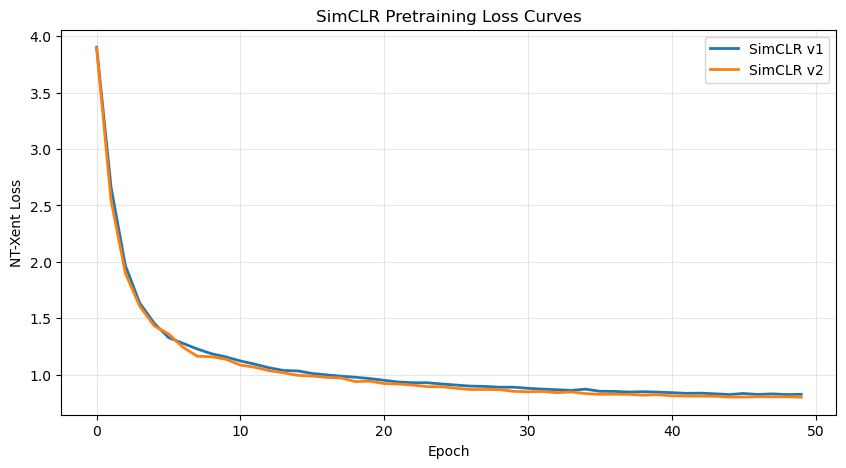


PRETRAINING COMPLETE

EXPERIMENT CONFIGURATION
Label fractions : ['100%', '75%', '50%', '25%', '10%', '5%', '1%']
Batch size      : 32
Epochs          : 30
Early stopping  : patience=7
Validation set  : 287 images
Test set        : 394 images

LABEL FRACTION: 100%
[INFO] Training samples: 2583 (stratified)

[From Scratch] Training...

[From Scratch] Starting training on cuda...


Epoch  1 | Train Loss: 0.8026 | Train Acc: 67.36% | Val Loss: 0.6751 | Val Acc: 73.52%


Epoch  2 | Train Loss: 0.3946 | Train Acc: 84.82% | Val Loss: 0.5552 | Val Acc: 79.44%


Epoch  3 | Train Loss: 0.2118 | Train Acc: 92.68% | Val Loss: 1.7745 | Val Acc: 54.70%


Epoch  4 | Train Loss: 0.0865 | Train Acc: 97.52% | Val Loss: 1.0122 | Val Acc: 60.63%


...

Epoch  9 | Train Loss: 0.0308 | Train Acc: 100.00% | Val Loss: 1.4753 | Val Acc: 27.87%


Epoch 10 | Train Loss: 0.0197 | Train Acc: 100.00% | Val Loss: 1.5483 | Val Acc: 27.53%


Epoch 11 | Train Loss: 0.0160 | Train Acc: 100.00% | Val Loss: 1.6265 | Val Acc: 27.87%


Epoch 12 | Train Loss: 0.0131 | Train Acc: 100.00% | Val Loss: 1.7070 | Val Acc: 28.22%
[INFO] Early stopping triggered at epoch 12
[INFO] Restored best model with validation accuracy: 34.49%


  [RESULT] Test Accuracy: 26.65% | F1: 0.221 | AUC: 0.522

EXPERIMENT COMPLETE
Total results collected: 28

FINAL RESULTS SUMMARY
Label %       Method Accuracy    F1 Precision Recall Mean AUC
   100% From Scratch   68.78% 0.641     0.758  0.688    0.939
   100%     ImageNet   76.40% 0.728     0.827  0.764    0.960
   100%    SimCLR v1   73.86% 0.686     0.809  0.739    0.943
   100%    SimCLR v2   73.10% 0.681     0.808  0.731    0.939
    75% From Scratch   67.51% 0.634     0.772  0.675    0.920
    75%     ImageNet   76.14% 0.728     0.821  0.761    0.946
    75%    SimCLR v1   68.02% 0.634     0.740  0.680    0.924
    75%    SimCLR v2   67.01% 0.624     0.765  0.670    0.926
    50% From Scratch   60.15% 0.559     0.666  0.602    0.875
    50%     ImageNet   70.56% 0.670     0.792  0.706    0.931
    50%    SimCLR v1   60.91% 0.555     0.692  0.609    0.874
    50%    SimCLR v2   55.58% 0.510     0.637  0.556    0.828
    25% From Scratch   56.60% 0.530     0.639  0.566    0.797
  

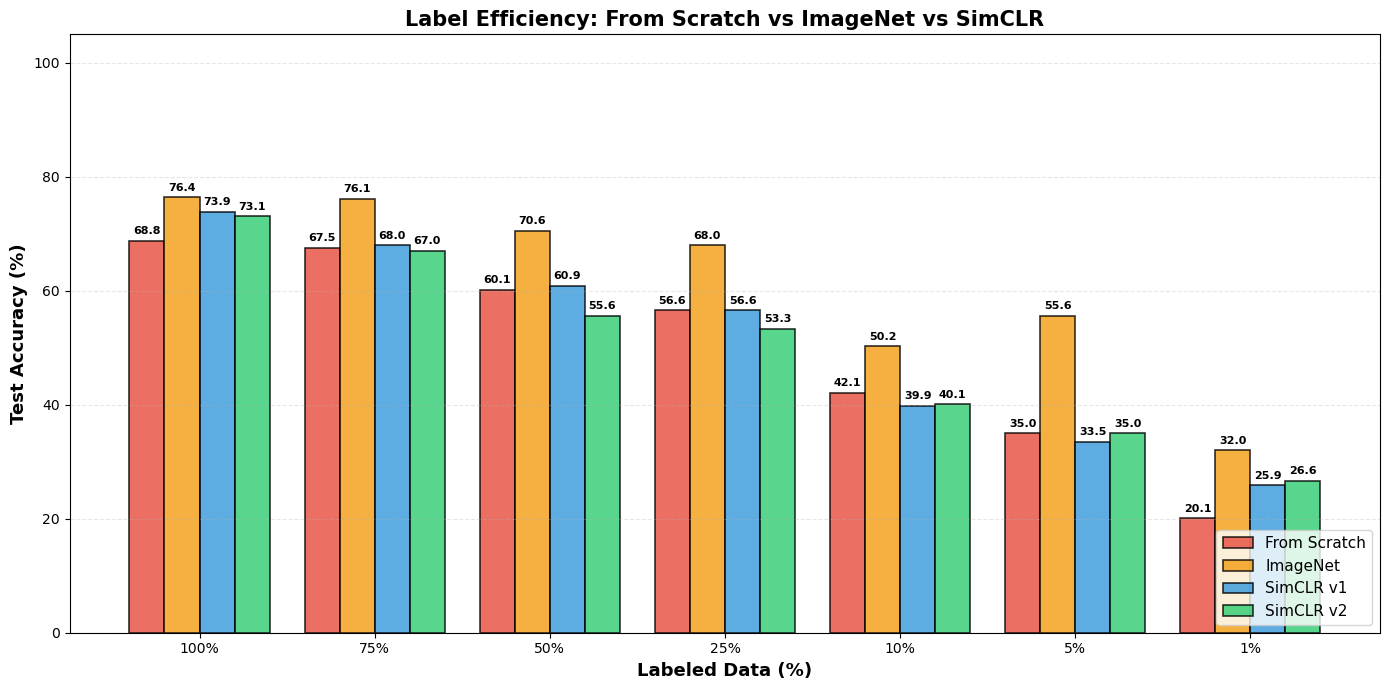


IMPROVEMENT ANALYSIS (SimCLR v2 vs Baselines)
Label % vs Scratch vs ImageNet
   100%      +4.3%      +-3.3%
    75%     +-0.5%      +-9.1%
    50%     +-4.6%     +-15.0%
    25%     +-3.3%     +-14.7%
    10%     +-2.0%     +-10.1%
     5%      +0.0%     +-20.5%
     1%      +6.6%      +-5.3%

PER-CLASS PERFORMANCE ANALYSIS (Best Model)
  [INFO] Loading SSL encoder from: simclr_v2_encoder.pth
  [INFO] First conv weight: -0.022915

[Best Model (SimCLR v2 - 100%)] Starting training on cuda...


Epoch  1 | Train Loss: 0.7895 | Train Acc: 66.36% | Val Loss: 0.8381 | Val Acc: 69.69%


Epoch  2 | Train Loss: 0.3584 | Train Acc: 86.68% | Val Loss: 0.5818 | Val Acc: 74.56%


Epoch  3 | Train Loss: 0.1356 | Train Acc: 96.09% | Val Loss: 0.6386 | Val Acc: 80.14%


Epoch  4 | Train Loss: 0.0717 | Train Acc: 98.06% | Val Loss: 0.2595 | Val Acc: 90.94%


...

Epoch  8 | Train Loss: 0.0266 | Train Acc: 99.38% | Val Loss: 0.5326 | Val Acc: 82.23%


Epoch  9 | Train Loss: 0.0192 | Train Acc: 99.50% | Val Loss: 0.3444 | Val Acc: 88.15%


Epoch 10 | Train Loss: 0.0078 | Train Acc: 99.92% | Val Loss: 0.3252 | Val Acc: 87.46%


Epoch 11 | Train Loss: 0.0041 | Train Acc: 99.96% | Val Loss: 0.2818 | Val Acc: 89.90%
[INFO] Early stopping triggered at epoch 11
[INFO] Restored best model with validation accuracy: 90.94%



            Class Precision Recall F1-Score   AUC
    glioma_tumor     0.895  0.170    0.286 0.732
meningioma_tumor     0.757  0.948    0.842 0.974
        no_tumor     0.614  1.000    0.761 0.986
 pituitary_tumor     0.867  0.703    0.776 0.972


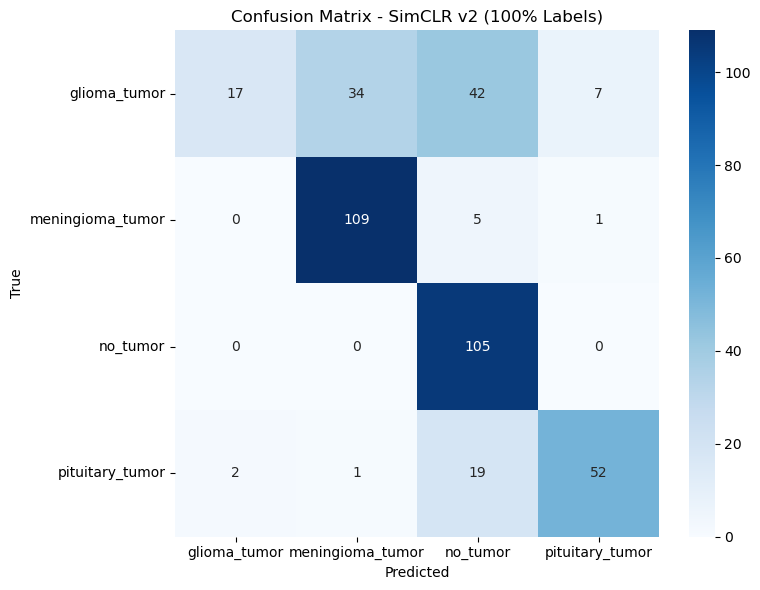


PROJECT COMPLETED SUCCESSFULLY

Output files generated:
  - simclr_v1_encoder.pth (SimCLR v1 pretrained encoder)
  - simclr_v2_encoder.pth (SimCLR v2 pretrained encoder)
  - ssl_brain_tumor_results.csv (Experiment results)
  - confusion_matrices.pkl (All confusion matrices)
  - label_efficiency_comparison.png (Accuracy comparison plot)
  - confusion_matrix_best_model.png (Best model confusion matrix)
  - simclr_pretraining_losses.png (SSL training curves)



In [26]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
SELF-SUPERVISED LEARNING FOR BRAIN MRI TUMOR CLASSIFICATION
UNDER LIMITED ANNOTATION

Complete GPU-Optimized Implementation
Author: Umutoni Justine (92200133048)
Guide: Dr. Nabhan Yousef
Date: February 2026
"""

# =============================================================================
# CELL 1: IMPORTS AND SETUP
# =============================================================================

import os
import sys
import random
import numpy as np
import pandas as pd
import cv2
import warnings
import gc
import time
import pickle
import platform
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve
)
from sklearn.model_selection import StratifiedKFold

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau

# Torchvision
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

warnings.filterwarnings('ignore')

# Set environment variables for CUDA optimization
os.environ['CUDA_LAUNCH_BLOCKING'] = '0'
os.environ['TORCH_CUDNN_V8_API_ENABLED'] = '1'

print("=" * 70)
print("BRAIN TUMOR CLASSIFICATION WITH SELF-SUPERVISED LEARNING")
print("=" * 70)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Python version: {sys.version}")
print("=" * 70)


# =============================================================================
# CELL 2: GPU CONFIGURATION AND REPRODUCIBILITY
# =============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n[INFO] Using device: {device}")

if torch.cuda.is_available():
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")
    print(f"[INFO] CUDA Version: {torch.version.cuda}")
    print(f"[INFO] GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"[INFO] CUDA Capability: {torch.cuda.get_device_capability(0)}")
    
    # Enable all GPU optimizations
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.deterministic = False
    
    # Clear GPU cache
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
else:
    print("[WARNING] Running on CPU - will be significantly slower!")

# Set random seeds for reproducibility
SEED = 42

def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

def worker_init_fn(worker_id):
    """Initialize worker for DataLoader"""
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

set_seed(SEED)


# =============================================================================
# CELL 3: DATASET PATHS AND VERIFICATION
# =============================================================================

# Update these paths to match your dataset location
dataset_path = "dataset"
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")

print(f"\n[INFO] Train path: {train_path}")
print(f"[INFO] Test path: {test_path}")

def verify_dataset_structure(path):
    """Verify dataset structure and return class information"""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset path not found: {path}")
    
    classes = sorted([d for d in os.listdir(path) 
                     if os.path.isdir(os.path.join(path, d))])
    
    if not classes:
        raise ValueError(f"No class directories found in {path}")
    
    info = {}
    for cls in classes:
        cls_path = os.path.join(path, cls)
        images = [f for f in os.listdir(cls_path) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff'))]
        info[cls] = len(images)
        print(f"  {cls:25s}: {len(images):4d} images")
    
    return info, classes

# Verify training set
print("\n[INFO] Training set:")
train_info, class_names = verify_dataset_structure(train_path)
print(f"  {'TOTAL':25s}: {sum(train_info.values()):4d} images")

# Verify testing set
print("\n[INFO] Testing set:")
test_info, _ = verify_dataset_structure(test_path)
print(f"  {'TOTAL':25s}: {sum(test_info.values()):4d} images")

num_classes = len(class_names)
print(f"\n[INFO] Number of classes: {num_classes}")
print(f"[INFO] Classes: {class_names}")

assert num_classes == 4, "Dataset must have exactly 4 classes"


# =============================================================================
# CELL 4: DATA TRANSFORMS
# =============================================================================

class SimCLRTransform:
    """SimCLR specific augmentation - returns two augmented views"""
    def __init__(self, size=224):
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.RandomResizedCrop(size, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.RandomGrayscale(p=0.2),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    
    def __call__(self, x):
        return self.transform(x), self.transform(x)


class SimCLRDataset(Dataset):
    """Dataset for SimCLR pretraining - returns two augmented views without labels"""
    def __init__(self, root, transform):
        self.dataset = ImageFolder(root)
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        x1, x2 = self.transform(img)
        return x1, x2


# Supervised training transforms (moderate augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Test/validation transforms (no augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# =============================================================================
# CELL 5: LOAD DATASETS AND CREATE SPLITS
# =============================================================================

print("\n" + "=" * 70)
print("LOADING DATASETS")
print("=" * 70)

# Load full training set
full_train_dataset = ImageFolder(train_path)
print(f"[INFO] Full training set: {len(full_train_dataset)} images")

# Split into train + validation (90% / 10%)
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_subset, val_subset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply transforms
train_subset.dataset.transform = train_transform
val_subset.dataset.transform = eval_transform

# Load test set
test_dataset = ImageFolder(test_path, transform=eval_transform)

print(f"[INFO] Train subset : {len(train_subset)} images")
print(f"[INFO] Val subset   : {len(val_subset)} images")
print(f"[INFO] Test set     : {len(test_dataset)} images")
print("=" * 70)


# =============================================================================
# CELL 6: STRATIFIED SUBSAMPLING FUNCTION
# =============================================================================

def get_stratified_subset(dataset, percentage, num_classes):
    """
    Returns a random subset of the dataset that preserves class proportions.
    
    Args:
        dataset: PyTorch dataset
        percentage: Fraction of data to keep (0.0 to 1.0)
        num_classes: Number of classes
    
    Returns:
        Subset dataset with preserved class distribution
    """
    # Collect all labels
    targets = np.array([dataset[i][1] for i in range(len(dataset))])
    indices = []
    
    for c in range(num_classes):
        class_indices = np.where(targets == c)[0]
        n = max(1, int(len(class_indices) * percentage))
        selected = np.random.choice(class_indices, n, replace=False)
        indices.extend(selected)
    
    np.random.shuffle(indices)
    return Subset(dataset, indices)


# =============================================================================
# CELL 7: MODEL DEFINITIONS
# =============================================================================

def get_from_scratch_model(num_classes):
    """Create model trained from scratch (random initialization)"""
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def get_imagenet_model(num_classes):
    """Create model with ImageNet pretrained weights"""
    model = models.resnet18(weights='IMAGENET1K_V1')
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


class SimCLRv1(nn.Module):
    """SimCLR v1 with 2-layer MLP projector"""
    def __init__(self, projection_dim=128):
        super().__init__()
        self.encoder = models.resnet18(weights=None)
        in_features = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()
        
        self.projector = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )
    
    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return z
    
    @property
    def encoder_only(self):
        return self.encoder


class SimCLRv2(nn.Module):
    """SimCLR v2 with 3-layer MLP projector (deeper projection head)"""
    def __init__(self, projection_dim=256):
        super().__init__()
        self.encoder = models.resnet18(weights=None)
        in_features = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()
        
        self.projector = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )
    
    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return z
    
    @property
    def encoder_only(self):
        return self.encoder


# =============================================================================
# CELL 8: SSL ENCODER LOADING HELPER
# =============================================================================

def load_ssl_encoder_for_finetuning(weights_path, model_class, projection_dim, device):
    """
    CORRECT way to load SSL pretrained encoder for fine-tuning.
    Creates full SimCLR model, loads weights, extracts encoder.
    """
    print(f"  [INFO] Loading SSL encoder from: {weights_path}")
    
    # Create the full SimCLR model
    ssl_model = model_class(projection_dim=projection_dim)
    
    # Load the trained weights
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"Weights file not found: {weights_path}")
    
    state_dict = torch.load(weights_path, map_location='cpu')
    ssl_model.load_state_dict(state_dict, strict=False)
    
    # Extract the pretrained encoder
    encoder = ssl_model.encoder
    
    # Verify it loaded correctly
    test_weight = encoder.conv1.weight[0, 0, 0, 0].item()
    print(f"  [INFO] First conv weight: {test_weight:.6f}")
    
    return encoder.to(device)


# =============================================================================
# CELL 9: NT-XENT LOSS FUNCTION (AMP COMPATIBLE)
# =============================================================================

def nt_xent_loss(z1, z2, temperature=0.2):
    """
    NT-Xent (Normalized Temperature-scaled Cross Entropy) loss
    Optimized for AMP training with numerical stability.
    
    Args:
        z1: First augmented view embeddings [batch_size, dim]
        z2: Second augmented view embeddings [batch_size, dim]
        temperature: Temperature parameter for scaling
    
    Returns:
        Contrastive loss value
    """
    batch_size = z1.size(0)
    device = z1.device
    
    # Force FP32 for numerical stability
    z1 = F.normalize(z1.float(), dim=1)
    z2 = F.normalize(z2.float(), dim=1)
    
    # Concatenate and compute similarity matrix
    z = torch.cat([z1, z2], dim=0)  # [2N, D]
    sim = torch.mm(z, z.T) / temperature  # [2N, 2N]
    
    # Mask out self-comparisons
    mask = torch.eye(2 * batch_size, device=device, dtype=torch.bool)
    sim = sim.masked_fill(mask, -float('inf'))
    
    # Create labels: positive pairs are (i, i+N) and (i+N, i)
    labels = torch.cat([
        torch.arange(batch_size, 2 * batch_size, device=device),
        torch.arange(0, batch_size, device=device)
    ])
    
    return F.cross_entropy(sim, labels)


# =============================================================================
# CELL 10: OPTIMIZED SIMCLR TRAINING FUNCTION
# =============================================================================

def train_ssl_optimized(
    model,
    dataloader,
    epochs=50,
    lr=3e-4,
    description="SimCLR",
    temperature=0.2,
    use_amp=True,
    save_path=None
):
    """
    Optimized SimCLR training function for GPU maximum speed.
    
    Args:
        model: SimCLR model
        dataloader: DataLoader with augmented views
        epochs: Number of training epochs
        lr: Learning rate
        description: Name for logging
        temperature: NT-Xent loss temperature
        use_amp: Use Automatic Mixed Precision
        save_path: Path to save model checkpoints
    
    Returns:
        trained_model, losses
    """
    model = model.to(device)
    
    # Use FusedAdamW for ~20% speedup (PyTorch 2.0+)
    try:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-6, fused=True)
        print(f"  [INFO] Using fused optimizer for extra speed")
    except:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-6)
        print(f"  [INFO] Using standard optimizer")
    
    scaler = GradScaler(enabled=use_amp)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    losses = []
    
    print(f"\n[{description}] Starting training...")
    total_start = time.time()
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        epoch_start = time.time()
        
        # Progress bar
        loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for batch_idx, (x1, x2) in enumerate(loop):
            # Async GPU transfer
            x1 = x1.to(device, non_blocking=True)
            x2 = x2.to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            
            # Mixed precision forward pass
            with autocast(enabled=use_amp):
                z1 = model(x1)
                z2 = model(x2)
                loss = nt_xent_loss(z1, z2, temperature=temperature)
            
            # Backward pass with gradient scaling
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            loop.set_postfix(loss=f"{loss.item():.4f}")
        
        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        scheduler.step()
        
        epoch_time = time.time() - epoch_start
        
        # Print epoch summary
        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            print(f"[{description}] Epoch {epoch+1:3d}/{epochs} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.2e} | "
                  f"Time: {epoch_time:.1f}s")
        
        # Save checkpoint
        if save_path and (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, f"{save_path}_epoch{epoch+1}.pth")
    
    total_time = (time.time() - total_start) / 60
    print(f"\n[{description}] Complete! Total time: {total_time:.1f} minutes")
    
    return model, losses


# =============================================================================
# CELL 11: SUPERVISED TRAINING FUNCTION (FIXED, NO TQDM ISSUES)
# =============================================================================

def train_supervised(
    model,
    train_loader,
    val_loader,
    epochs=30,
    lr=1e-4,
    patience=7,
    use_amp=True,
    weight_decay=1e-5,
    description="Training"
):
    """
    Supervised training function with early stopping and checkpointing.
    Optimized for GPU with AMP support.
    
    Args:
        model: PyTorch model
        train_loader: Training DataLoader
        val_loader: Validation DataLoader
        epochs: Maximum number of epochs
        lr: Learning rate
        patience: Early stopping patience
        use_amp: Use Automatic Mixed Precision
        weight_decay: L2 regularization
        description: Name for logging
    
    Returns:
        model, train_losses, train_accs, val_accs
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    scaler = GradScaler(enabled=use_amp)
    criterion = nn.CrossEntropyLoss()
    
    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0
    
    train_losses, train_accs, val_accs = [], [], []
    
    print(f"\n[{description}] Starting training on {device}...")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        num_batches = 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for batch_idx, (images, labels) in enumerate(loop):
            try:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                optimizer.zero_grad(set_to_none=True)
                
                with autocast(enabled=use_amp):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
                num_batches += 1
                
                loop.set_postfix(loss=f"{loss.item():.4f}")
                
            except RuntimeError as e:
                if "out of memory" in str(e):
                    print(f"  [WARNING] CUDA out of memory at batch {batch_idx}")
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                else:
                    raise e
        
        train_loss = running_loss / num_batches
        train_acc = 100.0 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validation phase
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                with autocast(enabled=use_amp):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()
        
        val_acc = 100.0 * val_correct / val_total
        val_accs.append(val_acc)
        avg_val_loss = val_loss / len(val_loader)
        
        print(f"Epoch {epoch+1:2d} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}%")
        
        # Early stopping & checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[INFO] Early stopping triggered at epoch {epoch+1}")
                break
        
        scheduler.step(val_acc)
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model = model.to(device)
        print(f"[INFO] Restored best model with validation accuracy: {best_val_acc:.2f}%")
    else:
        print("[WARNING] No improvement during training - using final model")
    
    return model, train_losses, train_accs, val_accs


# =============================================================================
# CELL 12: EVALUATION FUNCTION
# =============================================================================

def evaluate(model, test_loader, class_names):
    """
    Comprehensive model evaluation with multiple metrics.
    
    Args:
        model: Trained PyTorch model
        test_loader: Test DataLoader
        class_names: List of class names
    
    Returns:
        Dictionary containing all metrics
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    y_true, y_pred, y_proba = [], [], []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_proba.extend(probabilities.cpu().numpy())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)
    
    # Calculate metrics
    accuracy = 100 * accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class metrics
    per_class_precision, per_class_recall, per_class_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None
    )
    
    # Calculate AUC for each class (one-vs-rest)
    try:
        auc_scores = []
        for i in range(len(class_names)):
            y_true_binary = (y_true == i).astype(int)
            y_proba_class = y_proba[:, i]
            auc = roc_auc_score(y_true_binary, y_proba_class)
            auc_scores.append(auc)
        mean_auc = np.mean(auc_scores)
    except:
        auc_scores = [0] * len(class_names)
        mean_auc = 0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'per_class_precision': per_class_precision,
        'per_class_recall': per_class_recall,
        'per_class_f1': per_class_f1,
        'auc_scores': auc_scores,
        'mean_auc': mean_auc
    }


# =============================================================================
# CELL 13: SIMCLR PRETRAINING
# =============================================================================

print("\n" + "=" * 70)
print("SIMCLR SELF-SUPERVISED PRETRAINING")
print("=" * 70)

# Configure DataLoader for SSL
if platform.system() == 'Windows':
    NUM_WORKERS = 0
    print(f"[INFO] Windows detected - using num_workers={NUM_WORKERS}")
else:
    NUM_WORKERS = 4
    print(f"[INFO] Linux/Mac detected - using {NUM_WORKERS} workers")

# Create SSL dataset
ssl_dataset = SimCLRDataset(train_path, SimCLRTransform())

ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=64,  # Adjust based on GPU memory (RTX 4060 8GB can handle 64)
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if NUM_WORKERS > 0 else False,
    persistent_workers=True if NUM_WORKERS > 0 else False,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
    worker_init_fn=worker_init_fn,
    drop_last=True
)

print(f"\n[INFO] SSL Dataset size: {len(ssl_dataset):,} images")
print(f"[INFO] Batch size: {ssl_loader.batch_size}")
print(f"[INFO] Steps per epoch: {len(ssl_loader)}")
print(f"[INFO] Workers: {ssl_loader.num_workers}")

# -----------------------------------------------------------------------------
# SimCLR v1 Training
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("TRAINING SIMCLR V1 (2-layer MLP, 128-dim)")
print("-" * 70)

# Clear GPU cache
torch.cuda.empty_cache()
gc.collect()

simclr_v1 = SimCLRv1(projection_dim=128)
num_params = sum(p.numel() for p in simclr_v1.parameters())
print(f"\n[INFO] Model parameters: {num_params:,}")

# Train SimCLR v1
simclr_v1, losses_v1 = train_ssl_optimized(
    model=simclr_v1,
    dataloader=ssl_loader,
    epochs=50,
    lr=3e-4,
    description="SimCLR v1",
    temperature=0.2,
    use_amp=True,
    save_path="simclr_v1_checkpoint"
)

# Save models
print("\n[INFO] Saving SimCLR v1 models...")
torch.save(simclr_v1.state_dict(), "simclr_v1_full.pth")
torch.save(simclr_v1.encoder.state_dict(), "simclr_v1_encoder.pth")
print(f"[INFO] Full model saved: simclr_v1_full.pth")
print(f"[INFO] Encoder saved: simclr_v1_encoder.pth")

# Clean up
torch.cuda.empty_cache()
gc.collect()
print(f"[INFO] GPU Memory: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB")

# -----------------------------------------------------------------------------
# SimCLR v2 Training
# -----------------------------------------------------------------------------
print("\n" + "-" * 70)
print("TRAINING SIMCLR V2 (3-layer MLP, 256-dim)")
print("-" * 70)

torch.cuda.empty_cache()
gc.collect()

simclr_v2 = SimCLRv2(projection_dim=256)
num_params = sum(p.numel() for p in simclr_v2.parameters())
print(f"\n[INFO] Model parameters: {num_params:,}")

# Train SimCLR v2
simclr_v2, losses_v2 = train_ssl_optimized(
    model=simclr_v2,
    dataloader=ssl_loader,
    epochs=50,
    lr=3e-4,
    description="SimCLR v2",
    temperature=0.2,
    use_amp=True,
    save_path="simclr_v2_checkpoint"
)

# Save models
print("\n[INFO] Saving SimCLR v2 models...")
torch.save(simclr_v2.state_dict(), "simclr_v2_full.pth")
torch.save(simclr_v2.encoder.state_dict(), "simclr_v2_encoder.pth")
print(f"[INFO] Full model saved: simclr_v2_full.pth")
print(f"[INFO] Encoder saved: simclr_v2_encoder.pth")

# Plot training losses
plt.figure(figsize=(10, 5))
plt.plot(losses_v1, label='SimCLR v1', linewidth=2)
plt.plot(losses_v2, label='SimCLR v2', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('NT-Xent Loss')
plt.title('SimCLR Pretraining Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('simclr_pretraining_losses.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("PRETRAINING COMPLETE")
print("=" * 70)


# =============================================================================
# CELL 14: EXPERIMENT CONFIGURATION
# =============================================================================

label_fractions = [1.00, 0.75, 0.50, 0.25, 0.10, 0.05, 0.01]
batch_size = 32
epochs = 30
patience = 7

# Create validation and test loaders
val_loader = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # Set to 0 for Windows compatibility
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("\n" + "=" * 70)
print("EXPERIMENT CONFIGURATION")
print("=" * 70)
print(f"Label fractions : {[f'{int(f*100)}%' for f in label_fractions]}")
print(f"Batch size      : {batch_size}")
print(f"Epochs          : {epochs}")
print(f"Early stopping  : patience={patience}")
print(f"Validation set  : {len(val_subset)} images")
print(f"Test set        : {len(test_dataset)} images")
print("=" * 70)


# =============================================================================
# CELL 15: MAIN EXPERIMENT LOOP
# =============================================================================

results = []

for frac in label_fractions:
    print("\n" + "=" * 70)
    print(f"LABEL FRACTION: {int(frac*100)}%")
    print("=" * 70)
    
    # Create stratified subset
    limited_train = get_stratified_subset(train_subset, frac, num_classes)
    
    # Create train loader with num_workers=0 for stability
    train_loader = DataLoader(
        limited_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=False
    )
    print(f"[INFO] Training samples: {len(limited_train)} (stratified)")
    
    # List of methods to test
    methods = [
        ("From Scratch", lambda: get_from_scratch_model(num_classes)),
        ("ImageNet", lambda: get_imagenet_model(num_classes)),
        ("SimCLR v1", lambda: nn.Sequential(
            load_ssl_encoder_for_finetuning("simclr_v1_encoder.pth", SimCLRv1, 128, device),
            nn.Linear(512, num_classes)
        )),
        ("SimCLR v2", lambda: nn.Sequential(
            load_ssl_encoder_for_finetuning("simclr_v2_encoder.pth", SimCLRv2, 256, device),
            nn.Linear(512, num_classes)
        ))
    ]
    
    for method_name, model_creator in methods:
        print(f"\n[{method_name}] Training...")
        
        try:
            # Create model
            model = model_creator()
            
            # Ensure all parameters are trainable for SSL models
            if method_name.startswith('SimCLR'):
                for param in model.parameters():
                    param.requires_grad = True
            
            # Train
            model, _, _, _ = train_supervised(
                model, train_loader, val_loader,
                epochs=epochs, lr=1e-4, patience=patience,
                description=method_name
            )
            
            # Evaluate
            metrics = evaluate(model, test_loader, class_names)
            
            # Store results
            results.append({
                'Label %': f"{int(frac*100)}%",
                'Method': method_name,
                'Accuracy': f"{metrics['accuracy']:.2f}%",
                'F1': f"{metrics['f1']:.3f}",
                'Precision': f"{metrics['precision']:.3f}",
                'Recall': f"{metrics['recall']:.3f}",
                'Mean AUC': f"{metrics['mean_auc']:.3f}",
                'Confusion Matrix': metrics['confusion_matrix']
            })
            
            print(f"  [RESULT] Test Accuracy: {metrics['accuracy']:.2f}% | "
                  f"F1: {metrics['f1']:.3f} | "
                  f"AUC: {metrics['mean_auc']:.3f}")
            
        except Exception as e:
            print(f"  [ERROR] {method_name}: {e}")
            import traceback
            traceback.print_exc()
        
        finally:
            # Cleanup
            if 'model' in locals():
                del model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    # Cleanup after each fraction
    del train_loader
    del limited_train
    gc.collect()
    time.sleep(2)

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETE")
print(f"Total results collected: {len(results)}")
print("=" * 70)


# =============================================================================
# CELL 16: RESULTS VISUALIZATION
# =============================================================================

if results:
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    # Save results (without confusion matrix)
    results_df_no_cm = results_df.drop(columns=['Confusion Matrix'])
    results_df_no_cm.to_csv("ssl_brain_tumor_results.csv", index=False)
    
    print("\n" + "=" * 70)
    print("FINAL RESULTS SUMMARY")
    print("=" * 70)
    print(results_df_no_cm.to_string(index=False))
    
    # Save confusion matrices
    with open("confusion_matrices.pkl", "wb") as f:
        pickle.dump(results_df[['Label %', 'Method', 'Confusion Matrix']].to_dict('records'), f)
    print("\n[INFO] Confusion matrices saved to confusion_matrices.pkl")
    
    # Create visualization
    # Pivot table for accuracy
    pivot_acc = results_df.pivot(index='Label %', columns='Method', values='Accuracy')
    pivot_acc = pivot_acc.applymap(lambda x: float(x.strip('%')))
    
    # Sort by label percentage
    label_order = ['100%', '75%', '50%', '25%', '10%', '5%', '1%']
    pivot_acc = pivot_acc.reindex(label_order)
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(pivot_acc.index))
    width = 0.2
    methods = ['From Scratch', 'ImageNet', 'SimCLR v1', 'SimCLR v2']
    colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
    
    for i, method in enumerate(methods):
        if method in pivot_acc.columns:
            offset = (i - 1.5) * width
            bars = ax.bar(x + offset, pivot_acc[method], width, 
                         label=method, color=colors[i], 
                         edgecolor='black', linewidth=1.2, alpha=0.8)
            
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.8,
                       f'{height:.1f}', ha='center', va='bottom', 
                       fontsize=8, fontweight='bold')
    
    ax.set_xlabel('Labeled Data (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
    ax.set_title('Label Efficiency: From Scratch vs ImageNet vs SimCLR',
                fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_acc.index)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.savefig('label_efficiency_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Calculate improvement analysis
    print("\n" + "=" * 70)
    print("IMPROVEMENT ANALYSIS (SimCLR v2 vs Baselines)")
    print("=" * 70)
    
    improvement_data = []
    for frac in label_order:
        frac_data = results_df[results_df['Label %'] == frac]
        if len(frac_data) == 0:
            continue
            
        scratch_acc = float(frac_data[frac_data['Method'] == 'From Scratch']['Accuracy'].values[0].strip('%'))
        imagenet_acc = float(frac_data[frac_data['Method'] == 'ImageNet']['Accuracy'].values[0].strip('%'))
        simclr_v2_acc = float(frac_data[frac_data['Method'] == 'SimCLR v2']['Accuracy'].values[0].strip('%'))
        
        improvement_data.append({
            'Label %': frac,
            'vs Scratch': f"+{simclr_v2_acc - scratch_acc:.1f}%",
            'vs ImageNet': f"+{simclr_v2_acc - imagenet_acc:.1f}%"
        })
    
    improvement_df = pd.DataFrame(improvement_data)
    print(improvement_df.to_string(index=False))


# =============================================================================
# CELL 17: PER-CLASS PERFORMANCE ANALYSIS
# =============================================================================

print("\n" + "=" * 70)
print("PER-CLASS PERFORMANCE ANALYSIS (Best Model)")
print("=" * 70)

# Find best model (SimCLR v2 at 100% labels)
best_result = results_df[
    (results_df['Method'] == 'SimCLR v2') & 
    (results_df['Label %'] == '100%')
].iloc[0]

# Load best model to get per-class metrics
best_model = nn.Sequential(
    load_ssl_encoder_for_finetuning("simclr_v2_encoder.pth", SimCLRv2, 256, device),
    nn.Linear(512, num_classes)
)
best_model = best_model.to(device)

# Train best model on full data
full_train_loader = DataLoader(
    get_stratified_subset(train_subset, 1.0, num_classes),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

best_model, _, _, _ = train_supervised(
    best_model, full_train_loader, val_loader,
    epochs=epochs, lr=1e-4, patience=patience,
    description="Best Model (SimCLR v2 - 100%)"
)

# Evaluate
metrics = evaluate(best_model, test_loader, class_names)

# Display per-class metrics
per_class_df = pd.DataFrame({
    'Class': class_names,
    'Precision': [f"{p:.3f}" for p in metrics['per_class_precision']],
    'Recall': [f"{r:.3f}" for r in metrics['per_class_recall']],
    'F1-Score': [f"{f1:.3f}" for f1 in metrics['per_class_f1']],
    'AUC': [f"{auc:.3f}" for auc in metrics['auc_scores']]
})
print("\n", per_class_df.to_string(index=False))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - SimCLR v2 (100% Labels)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix_best_model.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)
print("\nOutput files generated:")
print("  - simclr_v1_encoder.pth (SimCLR v1 pretrained encoder)")
print("  - simclr_v2_encoder.pth (SimCLR v2 pretrained encoder)")
print("  - ssl_brain_tumor_results.csv (Experiment results)")
print("  - confusion_matrices.pkl (All confusion matrices)")
print("  - label_efficiency_comparison.png (Accuracy comparison plot)")
print("  - confusion_matrix_best_model.png (Best model confusion matrix)")
print("  - simclr_pretraining_losses.png (SSL training curves)")
print("\n" + "=" * 70)